# Combination of Non-Destructive Assay and Machine Learning Techniques
## to Detect Replaced Pins in Spent Fuel Assemblies
### Fatima Ballout — Master's Thesis, University of Padova 2023-2024

---
This notebook reproduces the full analysis from the thesis:
1. Data exploration & visualization
2. Classification (binary: intact vs modified) — Extra Trees, Random Forest, KNN, LGBM
3. Regression (predict number of replaced pins) — Extra Trees, Random Forest, KNN, LGBM

**Four isotope scenarios**: Combined (U238 + U235 + Pu239), U238-only, U235-only, Pu239-only

## 0. Imports & Configuration

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerPatch
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, KFold
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, ExtraTreesRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 123
TEST_SIZE    = 0.2
N_FOLDS      = 5

# Paths to pre-processed parquet files
DATA_DIR = '/Users/fatimaballout/desktop/Thesis Work 2'

print('All imports successful.')

All imports successful.


## 1. Data Exploration & Visualization
### 1.1 Single Simulation File — Assembly Layout

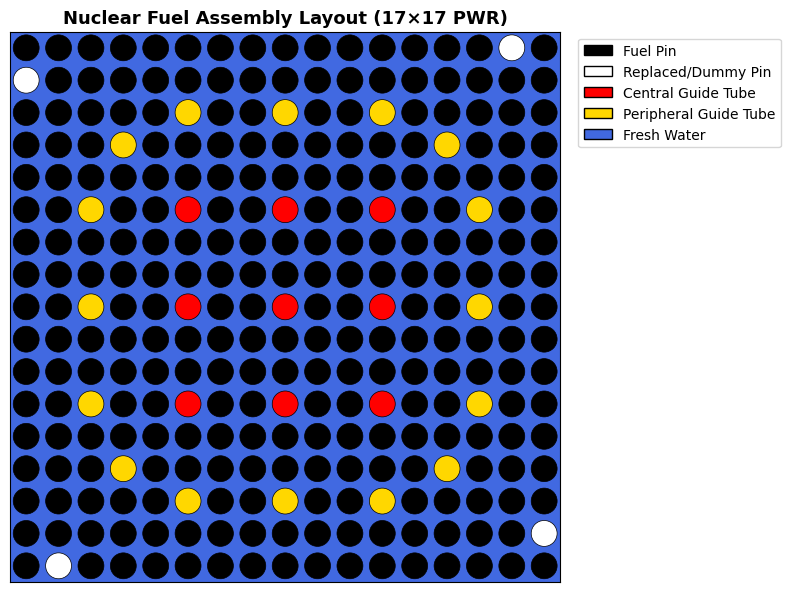

Figure 1: Assembly layout saved.


In [2]:
# Nuclear fuel assembly grid layout (17x17 PWR assembly)
# Values: 1=fuel pin, 33=replaced/dummy pin, 200s=guide tube positions
assembly_data = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 33, 1],
    [33, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 206, 1, 1, 211, 1, 1, 216, 1, 1, 1, 1, 1],
    [1, 1, 1, 204, 1, 1, 1, 1, 1, 1, 1, 1, 1, 221, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 201, 1, 1, 207, 1, 1, 212, 1, 1, 217, 1, 1, 223, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 202, 1, 1, 208, 1, 1, 213, 1, 1, 218, 1, 1, 224, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 203, 1, 1, 209, 1, 1, 214, 1, 1, 219, 1, 1, 225, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 205, 1, 1, 1, 1, 1, 1, 1, 1, 1, 222, 1, 1, 1],
    [1, 1, 1, 1, 1, 210, 1, 1, 215, 1, 1, 220, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 33],
    [1, 33, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
])

fig, ax = plt.subplots(figsize=(8, 8))
circle_radius = 0.4
central_tubes = [207, 212, 217, 208, 213, 218, 209, 214, 219]
peripheral_tubes = [206, 204, 201, 202, 203, 205, 210, 215, 220, 222, 225, 224, 223, 221, 216, 211]

for i in range(assembly_data.shape[0] + 1):
    for j in range(assembly_data.shape[1] + 1):
        rect = plt.Rectangle((j - 0.5, -i - 0.5), 1, 1, facecolor='royalblue', edgecolor='none')
        ax.add_patch(rect)

for i in range(assembly_data.shape[0]):
    for j in range(assembly_data.shape[1]):
        v = assembly_data[i, j]
        if v == 33:
            color = 'white'
        elif v in central_tubes:
            color = 'red'
        elif v in peripheral_tubes:
            color = 'gold'
        else:  # v == 1, fuel pin
            color = 'black'
        circle = plt.Circle((j, -i), circle_radius, facecolor=color, edgecolor='black', linewidth=0.5)
        ax.add_patch(circle)

ax.set_aspect('equal')
ax.set_xlim(-0.5, 16.5)
ax.set_ylim(-16.5, 0.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Nuclear Fuel Assembly Layout (17×17 PWR)', fontsize=13, fontweight='bold')

legend_handles = [
    mpatches.Patch(facecolor='black', edgecolor='black', label='Fuel Pin'),
    mpatches.Patch(facecolor='white', edgecolor='black', label='Replaced/Dummy Pin'),
    mpatches.Patch(facecolor='red', edgecolor='black', label='Central Guide Tube'),
    mpatches.Patch(facecolor='gold', edgecolor='black', label='Peripheral Guide Tube'),
    mpatches.Patch(facecolor='royalblue', edgecolor='black', label='Fresh Water'),
]
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout()
plt.savefig('assembly_layout.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1: Assembly layout saved.')

### 1.2 Flux Data Extraction from Simulation File

In [3]:
def extract_cell_data_v3(lines):
    """Parse neutron flux data from MCNP .o simulation output file."""
    cell_data_pattern = re.compile(r'^\s*([\d\.E+-]+)\s+([\d\.E+-]+)\s+([\d\.E+-]+)')
    data = []
    current_cell = None
    capture = False

    for line in lines:
        if 'cell' in line and re.search(r'\d+', line):
            current_cell = int(re.search(r'\d+', line).group())
            capture = True
        elif 'energy' in line and capture:
            continue
        elif current_cell is not None and capture:
            match = cell_data_pattern.match(line)
            if match:
                energy, flux, error = map(float, match.groups())
                data.append([current_cell, energy, flux, error])
            else:
                current_cell = None
                capture = False

    return pd.DataFrame(data, columns=['Cell', 'Energy', 'Flux', 'Error'])


def extract_cell_data_from_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    return extract_cell_data_v3(lines)


# Example: load and inspect one simulation file
sample_file = '/Users/fatimaballout/downloads/zD00401N_MODab_L0500600_5y_R_120_D05C9DEC485BD5A13F91D658208745C7FE43613FF1D170820D35C4FE42D5ED091BDC9D051.o'

if os.path.exists(sample_file):
    df_sample = extract_cell_data_from_file(sample_file)
    print(f'Sample file shape: {df_sample.shape}')
    print(f'Unique cells: {df_sample["Cell"].nunique()}')
    print(f'Energy bins: {df_sample["Energy"].nunique()}')
    print(df_sample.head())
else:
    print('Sample .o file not found. Skipping raw file parsing (using pre-processed parquet files).')
    df_sample = None

Sample file shape: (39130, 4)
Unique cells: 65
Energy bins: 602
   Cell        Energy          Flux   Error
0  1011  1.000000e-09  1.691620e-08  0.1572
1  1011  1.040300e-09  2.626120e-09  0.4134
2  1011  1.082100e-09  2.485440e-09  0.4539
3  1011  1.125700e-09  1.607180e-09  0.3986
4  1011  1.171000e-09  2.637420e-09  0.3712


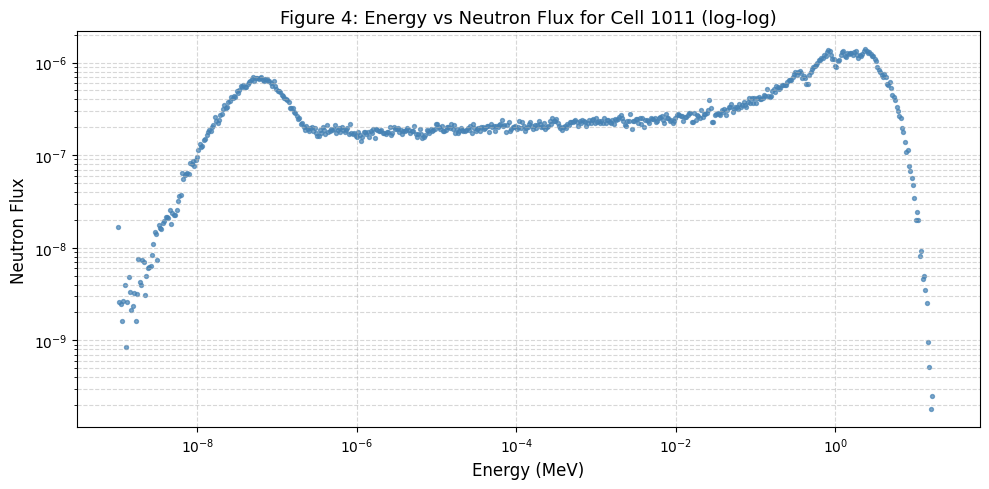

In [4]:
# Plot energy vs flux for cell 1011 (logarithmic scale)
if df_sample is not None:
    cell_data = df_sample[df_sample['Cell'] == 1011].copy()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(cell_data['Energy'], cell_data['Flux'], s=8, color='steelblue', alpha=0.7)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Energy (MeV)', fontsize=12)
    ax.set_ylabel('Neutron Flux', fontsize=12)
    ax.set_title('Figure 4: Energy vs Neutron Flux for Cell 1011 (log-log)', fontsize=13)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('energy_vs_flux_cell1011.png', dpi=150)
    plt.show()
else:
    print('Skipped (no sample file).')

## 2. Load Pre-Processed Machine Learning Datasets

All 15,984 simulation files have been processed:
- Flux convolved with cross-sections (U235, U238, Pu239)
- Summed over energy bins per cell → one feature per (cell, isotope) pair
- Pivoted: each row = one simulation file, columns = `Cell{id}_Flux_{isotope}`
- `MODab_Flag`: 0 = intact assembly, 1 = modified (replaced pins)
- `Total Replaced Pins`: count of replaced pins (0–130) for regression

In [5]:
# Load all datasets
df_combined_reg  = pd.read_parquet(os.path.join(DATA_DIR, 'merged_dataframe.parquet'))
df_u238_clf      = pd.read_parquet(os.path.join(DATA_DIR, 'U238_filtered_dataframe_with_file.parquet'))
df_u235_clf      = pd.read_parquet(os.path.join(DATA_DIR, 'U235_filtered_dataframe_with_file.parquet'))
df_pu239_clf     = pd.read_parquet(os.path.join(DATA_DIR, 'pu239_filtered_dataframe_with_file.parquet'))
df_u238_reg      = pd.read_parquet(os.path.join(DATA_DIR, 'filtered_dataframe_No_U238.parquet'))
df_u235_reg      = pd.read_parquet(os.path.join(DATA_DIR, 'filtered_dataframe_No_U235.parquet'))
df_pu239_reg     = pd.read_parquet(os.path.join(DATA_DIR, 'filtered_dataframe_No_PU239.parquet'))

print('=== Dataset Shapes ===')
print(f'Combined (regression):   {df_combined_reg.shape}')
print(f'U238 classification:     {df_u238_clf.shape}')
print(f'U235 classification:     {df_u235_clf.shape}')
print(f'Pu239 classification:    {df_pu239_clf.shape}')
print(f'U238 regression:         {df_u238_reg.shape}')
print(f'U235 regression:         {df_u235_reg.shape}')
print(f'Pu239 regression:        {df_pu239_reg.shape}')

print('\n=== Class Balance (MODab_Flag) ===')
print(df_u238_clf['MODab_Flag'].value_counts())
print('0 = intact assembly, 1 = modified (replaced pins)')

=== Dataset Shapes ===
Combined (regression):   (14898, 198)
U238 classification:     (14898, 67)
U235 classification:     (14898, 67)
Pu239 classification:    (14898, 67)
U238 regression:         (14898, 67)
U235 regression:         (14898, 67)
Pu239 regression:        (14898, 67)

=== Class Balance (MODab_Flag) ===
1    12154
0     2744
Name: MODab_Flag, dtype: int64
0 = intact assembly, 1 = modified (replaced pins)


In [6]:
# Build combined classification dataset from merged_dataframe
flux_cols = [c for c in df_combined_reg.columns if 'Flux' in c]
df_combined_clf = df_combined_reg[['File Name', 'MODab_Flag'] + flux_cols].copy()
df_combined_clf.rename(columns={'File Name': 'File'}, inplace=True)
print('Combined classification shape:', df_combined_clf.shape)
print('Features (flux columns):', len(flux_cols))

Combined classification shape: (14898, 197)
Features (flux columns): 195


Total Replaced Pins distribution:
count    14898.000000
mean        53.480534
std         48.893059
min          0.000000
25%          7.000000
50%         38.000000
75%        114.000000
max        130.000000
Name: Total Replaced Pins, dtype: float64


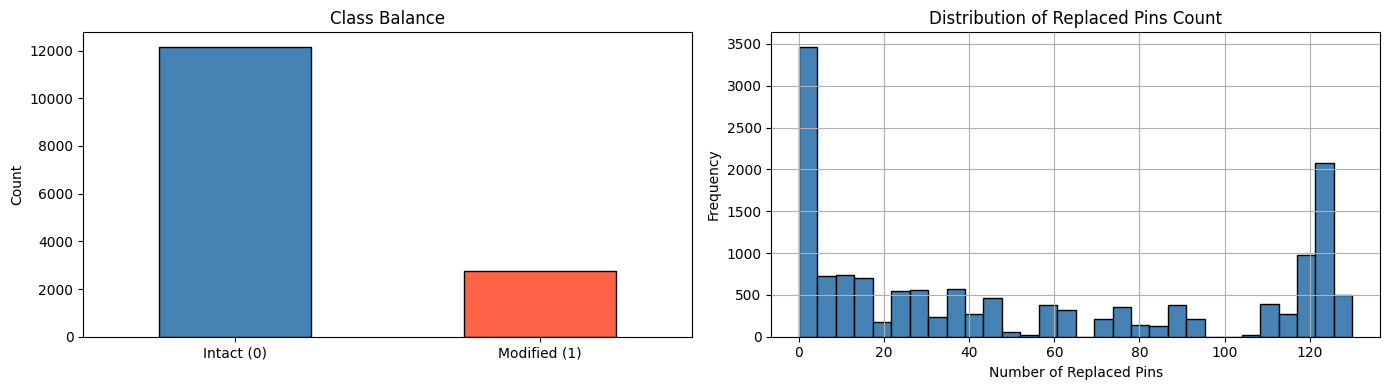

In [7]:
# Summary statistics
print('Total Replaced Pins distribution:')
print(df_combined_reg['Total Replaced Pins'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_u238_clf['MODab_Flag'].value_counts().plot.bar(ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_xticklabels(['Intact (0)', 'Modified (1)'], rotation=0)
axes[0].set_title('Class Balance', fontsize=12)
axes[0].set_ylabel('Count')

df_combined_reg['Total Replaced Pins'].hist(ax=axes[1], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Replaced Pins Count', fontsize=12)
axes[1].set_xlabel('Number of Replaced Pins')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('data_overview.png', dpi=150)
plt.show()

## 3. Helper Functions

In [8]:
def prepare_clf_data(df, target='MODab_Flag', drop_cols=None):
    """Split dataframe into X, y for classification."""
    cols_to_drop = [target]
    if drop_cols:
        cols_to_drop += drop_cols
    # Drop non-numeric identifier columns
    for col in df.columns:
        if df[col].dtype == object:
            cols_to_drop.append(col)
    X = df.drop(columns=list(set(cols_to_drop)), errors='ignore')
    y = df[target]
    return X, y


def prepare_reg_data(df, target='Total Replaced Pins'):
    """Split dataframe into X, y for regression (modified files only)."""
    cols_to_drop = [target, 'MODab_Flag']
    for col in df.columns:
        if df[col].dtype == object:
            cols_to_drop.append(col)
    X = df.drop(columns=list(set(cols_to_drop)), errors='ignore')
    y = df[target]
    return X, y


def cross_val_classification(model, X, y, n_folds=N_FOLDS):
    """Run stratified k-fold cross-validation for classification."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc']
    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring, return_train_score=False)
    df_cv = pd.DataFrame({
        'Fold': range(1, n_folds + 1),
        'Accuracy':  cv_results['test_accuracy'],
        'Precision': cv_results['test_precision_weighted'],
        'Recall':    cv_results['test_recall_weighted'],
        'F1':        cv_results['test_f1_weighted'],
        'AUC':       cv_results['test_roc_auc'],
    })
    return df_cv


def cross_val_regression(model, X, y, n_folds=N_FOLDS):
    """Run k-fold cross-validation for regression."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
    cv_results = cross_validate(model, X, y, cv=kf, scoring=scoring, return_train_score=False)
    df_cv = pd.DataFrame({
        'Fold': range(1, n_folds + 1),
        'MAE':  -cv_results['test_neg_mean_absolute_error'],
        'RMSE': -cv_results['test_neg_root_mean_squared_error'],
        'R2':    cv_results['test_r2'],
    })
    return df_cv


def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name, isotope_label):
    """Train, evaluate, plot confusion matrix and ROC curve."""
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(f'\n--- {model_name} | {isotope_label} ---')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1:        {f1:.4f}')
    if auc: print(f'AUC-ROC:   {auc:.4f}')
    print(classification_report(y_test, y_pred, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix\n{model_name} | {isotope_label}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # ROC Curve
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
        axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curve\n{model_name} | {isotope_label}')
        axes[1].legend(loc='lower right')
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f'{model_name.replace(" ", "_")}_{isotope_label}_clf.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()

    return {'model': model_name, 'isotope': isotope_label,
            'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}


def evaluate_regressor(model, X_train, X_test, y_train, y_test, model_name, isotope_label):
    """Train, evaluate, plot prediction error and residuals."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f'\n--- {model_name} | {isotope_label} ---')
    print(f'MAE:  {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R²:   {r2:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Prediction error plot
    axes[0].scatter(y_test, y_pred, alpha=0.4, s=10, color='steelblue')
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    axes[0].set_xlabel('Actual Replaced Pins')
    axes[0].set_ylabel('Predicted Replaced Pins')
    axes[0].set_title(f'Prediction Error\n{model_name} | {isotope_label}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Residuals plot
    residuals = y_test - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.4, s=10, color='tomato')
    axes[1].axhline(0, color='black', lw=1.5, ls='--')
    axes[1].set_xlabel('Predicted Replaced Pins')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'Residuals Plot\n{model_name} | {isotope_label}')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f'{model_name.replace(" ", "_")}_{isotope_label}_reg.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()

    return {'model': model_name, 'isotope': isotope_label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}


print('Helper functions defined.')

Helper functions defined.


## 4. Classification Models
**Task**: Binary classification — intact assembly (0) vs modified/replaced pins (1)

**Models**: Extra Trees, Random Forest, KNN, LightGBM  
**Scenarios**: Combined (all isotopes), U238-only, U235-only, Pu239-only

In [9]:
# Define classifiers with thesis hyperparameters
classifiers = {
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100, criterion='gini', max_depth=None,
        max_features='sqrt', min_samples_leaf=1, min_samples_split=2,
        bootstrap=False, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, criterion='gini', max_depth=None,
        max_features='sqrt', min_samples_leaf=1, min_samples_split=2,
        bootstrap=True, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, weights='uniform', metric='minkowski'
    ),
    'LGBM': lgb.LGBMClassifier(
        n_estimators=100, learning_rate=0.1, num_leaves=31,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
    ),
}

# Classification datasets
clf_datasets = {
    'Combined': df_combined_clf,
    'U238':     df_u238_clf,
    'U235':     df_u235_clf,
    'Pu239':    df_pu239_clf,
}

print('Classifiers and datasets ready.')

Classifiers and datasets ready.


### 4.1 Combined Analysis (U238 + U235 + Pu239)

Combined — Train: (11918, 195), Test: (2980, 195)

--- Extra Trees | Combined ---
Accuracy:  0.9926
Precision: 0.9926
Recall:    0.9926
F1:        0.9926
AUC-ROC:   0.9991
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       549
           1       0.99      1.00      1.00      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.98      0.99      2980
weighted avg       0.99      0.99      0.99      2980



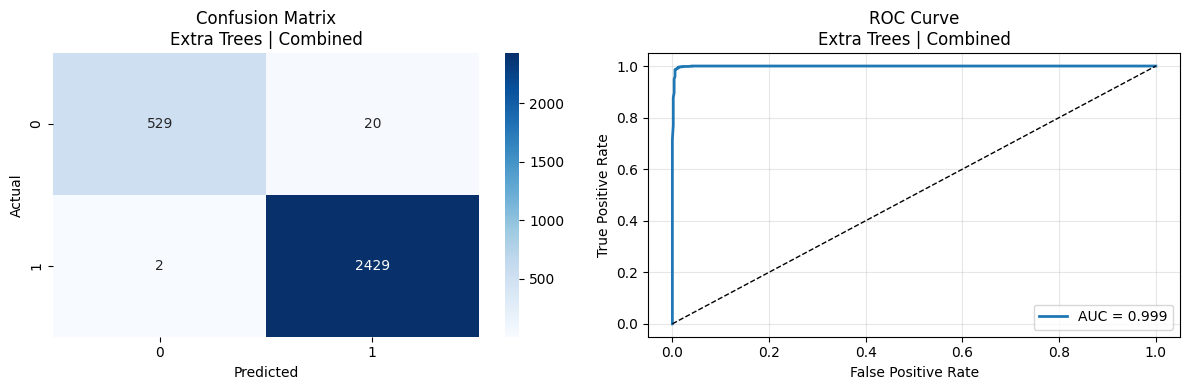


--- Random Forest | Combined ---
Accuracy:  0.9909
Precision: 0.9909
Recall:    0.9909
F1:        0.9909
AUC-ROC:   0.9987
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       549
           1       0.99      1.00      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.98      0.98      2980
weighted avg       0.99      0.99      0.99      2980



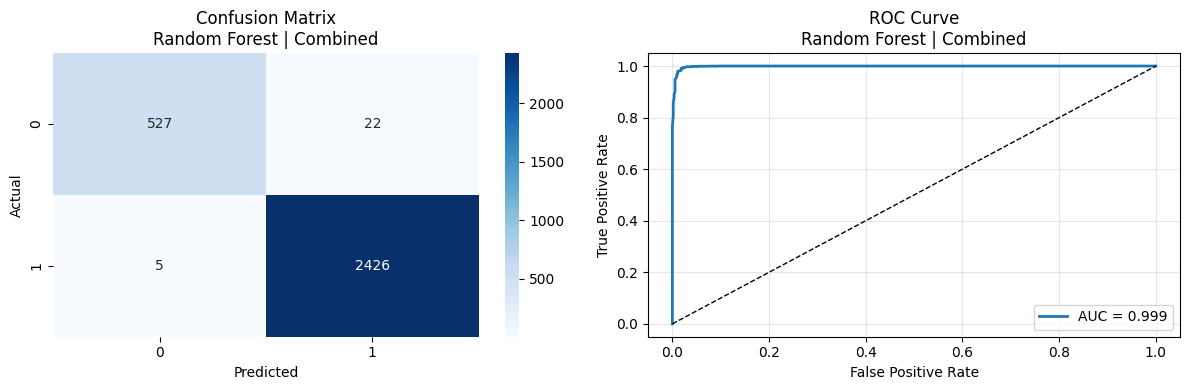


--- KNN | Combined ---
Accuracy:  0.9688
Precision: 0.9725
Recall:    0.9688
F1:        0.9696
AUC-ROC:   0.9940
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       549
           1       1.00      0.96      0.98      2431

    accuracy                           0.97      2980
   macro avg       0.93      0.98      0.95      2980
weighted avg       0.97      0.97      0.97      2980



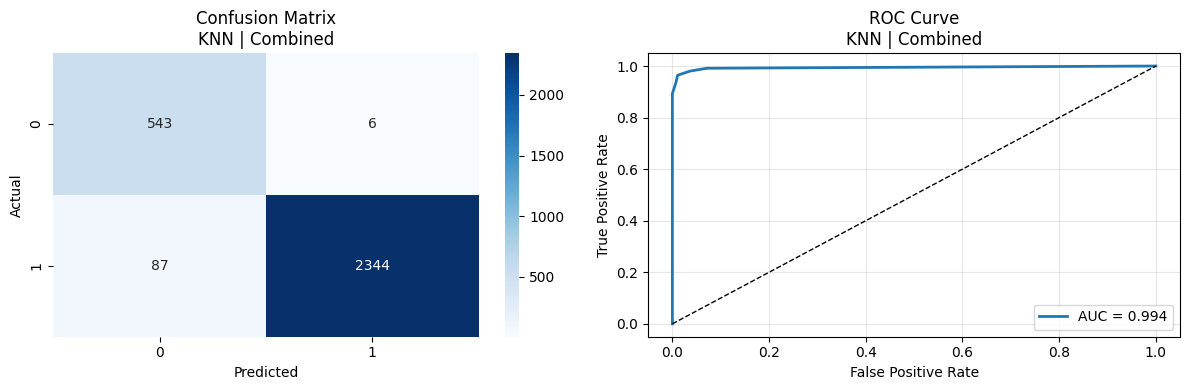


--- LGBM | Combined ---
Accuracy:  0.9889
Precision: 0.9890
Recall:    0.9889
F1:        0.9890
AUC-ROC:   0.9990
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       549
           1       1.00      0.99      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.98      0.98      0.98      2980
weighted avg       0.99      0.99      0.99      2980



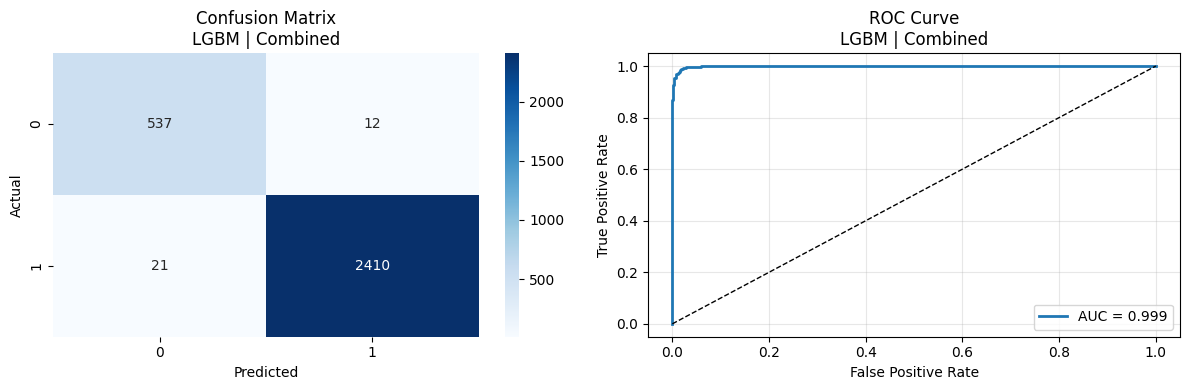

In [10]:
isotope_label = 'Combined'
df_clf = clf_datasets[isotope_label]
X, y = prepare_clf_data(df_clf)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=42, stratify=y
)
print(f'{isotope_label} — Train: {X_train.shape}, Test: {X_test.shape}')

clf_results_combined = []
for model_name, model in classifiers.items():
    result = evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name, isotope_label)
    clf_results_combined.append(result)

In [11]:
# Cross-validation for Combined
print(f'=== 5-Fold Cross-Validation — {isotope_label} ===')
for model_name, model in classifiers.items():
    import copy
    m = copy.deepcopy(model)
    cv_df = cross_val_classification(m, X_scaled, y)
    print(f'\n{model_name}:')
    print(cv_df.to_string(index=False))
    print(f'  Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
    print(f'  Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

=== 5-Fold Cross-Validation — Combined ===

Extra Trees:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.995302   0.995316 0.995302 0.995282 0.999872
    2  0.995302   0.995316 0.995302 0.995282 0.999768
    3  0.996644   0.996658 0.996644 0.996632 0.999454
    4  0.994965   0.994982 0.994965 0.994941 0.999924
    5  0.993622   0.993672 0.993622 0.993578 0.998351
  Mean Accuracy: 0.9952 ± 0.0011
  Mean AUC:      0.9995 ± 0.0007

Random Forest:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.992953   0.992976 0.992953 0.992910 0.999202
    2  0.992617   0.992629 0.992617 0.992575 0.999641
    3  0.995973   0.995982 0.995973 0.995959 0.999294
    4  0.990937   0.990965 0.990937 0.990868 0.999751
    5  0.990601   0.990680 0.990601 0.990512 0.996918
  Mean Accuracy: 0.9926 ± 0.0021
  Mean AUC:      0.9990 ± 0.0012

KNN:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.964430   0.968528 0.964430 0.965381 0.991828
    2  0.972148   0.974693 0.9721

In [12]:
print(f'\n=== Comparative Classification Results — {isotope_label} ===')
df_summary_clf_combined = pd.DataFrame(clf_results_combined)
print(df_summary_clf_combined.to_string(index=False))


=== Comparative Classification Results — Combined ===
        model  isotope  accuracy  precision   recall       f1      auc
  Extra Trees Combined  0.992617   0.992644 0.992617 0.992570 0.999108
Random Forest Combined  0.990940   0.990937 0.990940 0.990884 0.998664
          KNN Combined  0.968792   0.972476 0.968792 0.969600 0.993981
         LGBM Combined  0.988926   0.989025 0.988926 0.988961 0.998973


### 4.2 U238-Only Classification

U238 — Train: (11918, 65), Test: (2980, 65)

--- Extra Trees | U238 ---
Accuracy:  0.9980
Precision: 0.9980
Recall:    0.9980
F1:        0.9980
AUC-ROC:   0.9997
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       549
           1       1.00      1.00      1.00      2431

    accuracy                           1.00      2980
   macro avg       1.00      1.00      1.00      2980
weighted avg       1.00      1.00      1.00      2980



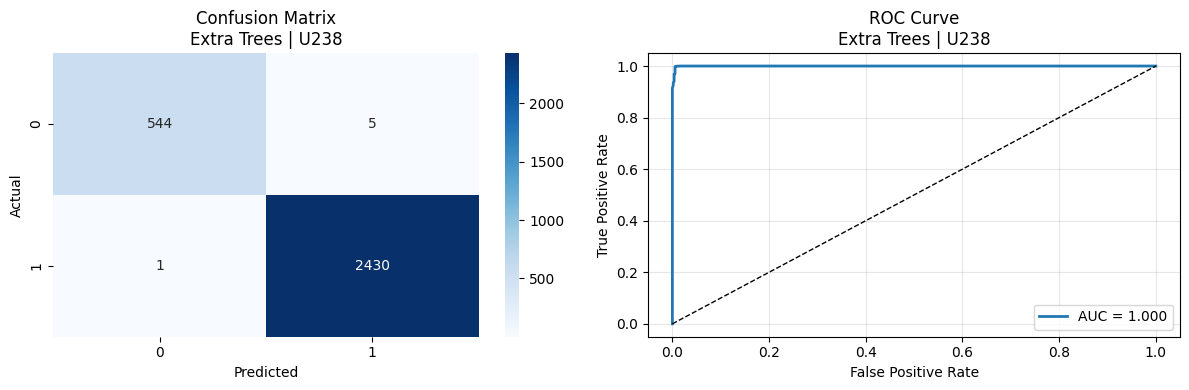


--- Random Forest | U238 ---
Accuracy:  0.9940
Precision: 0.9940
Recall:    0.9940
F1:        0.9940
AUC-ROC:   0.9994
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       549
           1       1.00      1.00      1.00      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.99      0.99      2980
weighted avg       0.99      0.99      0.99      2980



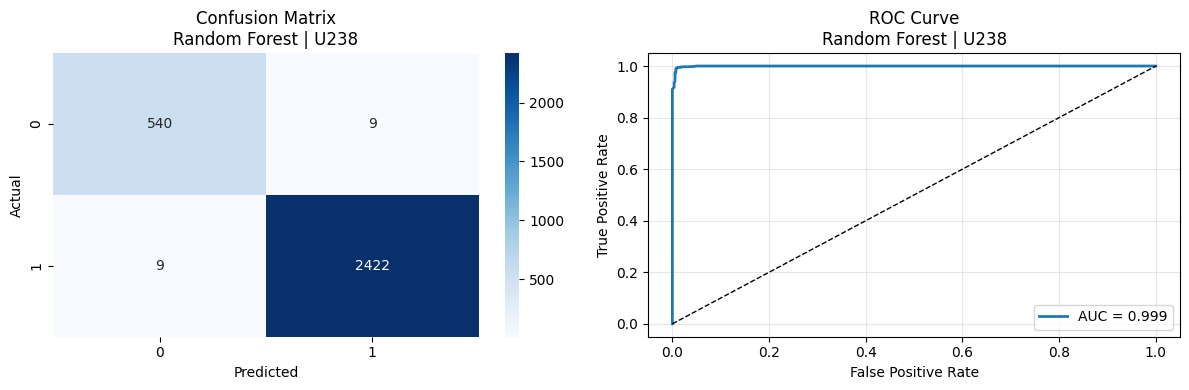


--- KNN | U238 ---
Accuracy:  0.9527
Precision: 0.9620
Recall:    0.9527
F1:        0.9546
AUC-ROC:   0.9909
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       549
           1       1.00      0.94      0.97      2431

    accuracy                           0.95      2980
   macro avg       0.90      0.97      0.93      2980
weighted avg       0.96      0.95      0.95      2980



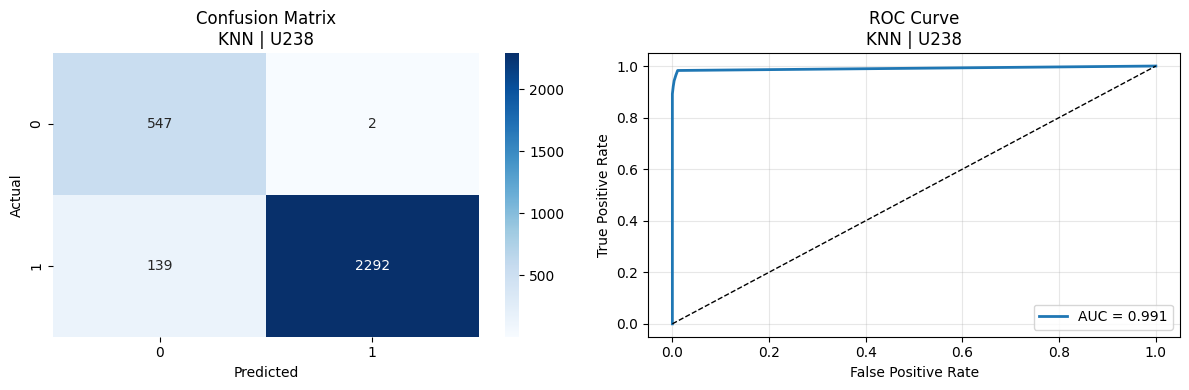


--- LGBM | U238 ---
Accuracy:  0.9762
Precision: 0.9781
Recall:    0.9762
F1:        0.9766
AUC-ROC:   0.9982
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       549
           1       1.00      0.97      0.99      2431

    accuracy                           0.98      2980
   macro avg       0.95      0.98      0.96      2980
weighted avg       0.98      0.98      0.98      2980



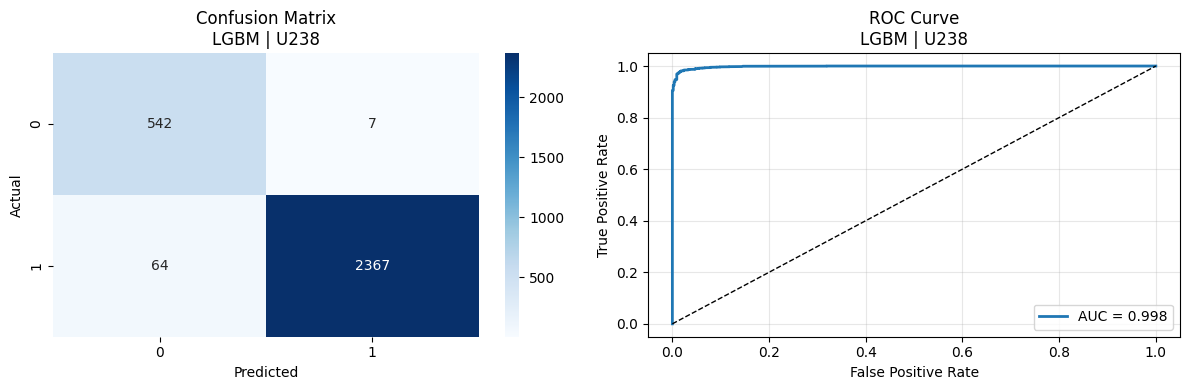

In [13]:
isotope_label = 'U238'
df_clf = clf_datasets[isotope_label]
X, y = prepare_clf_data(df_clf)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=42, stratify=y
)
print(f'{isotope_label} — Train: {X_train.shape}, Test: {X_test.shape}')

clf_results_u238 = []
for model_name, model in classifiers.items():
    result = evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name, isotope_label)
    clf_results_u238.append(result)

In [14]:
print(f'=== 5-Fold Cross-Validation — {isotope_label} ===')
for model_name, model in classifiers.items():
    m = copy.deepcopy(model)
    cv_df = cross_val_classification(m, X_scaled, y)
    print(f'\n{model_name}:')
    print(cv_df.to_string(index=False))
    print(f'  Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')

=== 5-Fold Cross-Validation — U238 ===

Extra Trees:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.996309   0.996306 0.996309 0.996307 0.999906
    2  0.998322   0.998321 0.998322 0.998322 0.999916
    3  0.997315   0.997313 0.997315 0.997314 0.998234
    4  0.998322   0.998321 0.998322 0.998321 0.999905
    5  0.996307   0.996303 0.996307 0.996304 0.999287
  Mean Accuracy: 0.9973 ± 0.0010

Random Forest:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.990940   0.990934 0.990940 0.990936 0.999310
    2  0.992617   0.992644 0.992617 0.992628 0.998429
    3  0.993624   0.993611 0.993624 0.993608 0.996269
    4  0.993286   0.993297 0.993286 0.993291 0.999581
    5  0.989594   0.989639 0.989594 0.989612 0.998609
  Mean Accuracy: 0.9920 ± 0.0017

KNN:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.953691   0.962414 0.953691 0.955530 0.993476
    2  0.945973   0.958007 0.945973 0.948477 0.991744
    3  0.951678   0.960926 0.951678 0.953645 0.99

In [15]:
print(f'\n=== Comparative Classification Results — {isotope_label} ===')
df_summary_clf_u238 = pd.DataFrame(clf_results_u238)
print(df_summary_clf_u238.to_string(index=False))


=== Comparative Classification Results — U238 ===
        model isotope  accuracy  precision   recall       f1      auc
  Extra Trees    U238  0.997987   0.997987 0.997987 0.997984 0.999675
Random Forest    U238  0.993960   0.993960 0.993960 0.993960 0.999389
          KNN    U238  0.952685   0.961960 0.952685 0.954623 0.990898
         LGBM    U238  0.976174   0.978138 0.976174 0.976621 0.998192


### 4.3 U235-Only Classification

U235 — Train: (11918, 65), Test: (2980, 65)

--- Extra Trees | U235 ---
Accuracy:  0.9883
Precision: 0.9883
Recall:    0.9883
F1:        0.9882
AUC-ROC:   0.9982
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       549
           1       0.99      1.00      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.97      0.98      2980
weighted avg       0.99      0.99      0.99      2980



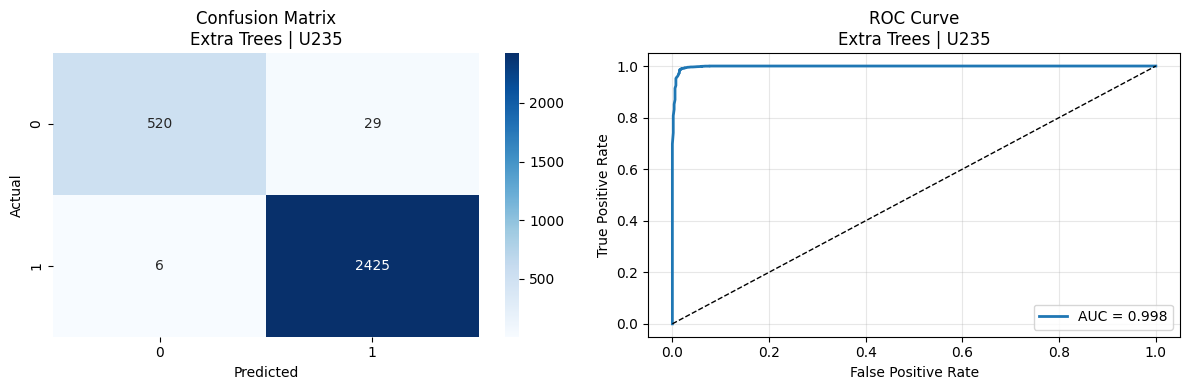


--- Random Forest | U235 ---
Accuracy:  0.9889
Precision: 0.9889
Recall:    0.9889
F1:        0.9888
AUC-ROC:   0.9982
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       549
           1       0.99      1.00      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.97      0.98      2980
weighted avg       0.99      0.99      0.99      2980



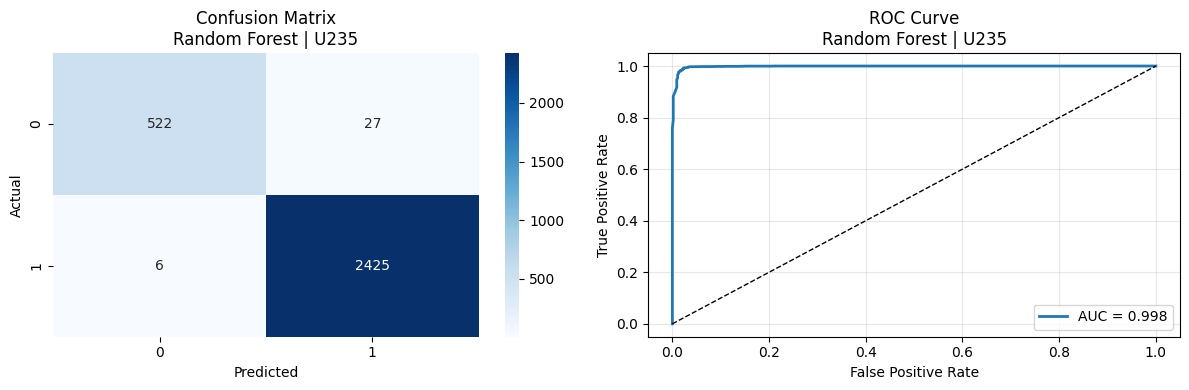


--- KNN | U235 ---
Accuracy:  0.9611
Precision: 0.9645
Recall:    0.9611
F1:        0.9620
AUC-ROC:   0.9887
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       549
           1       0.99      0.96      0.98      2431

    accuracy                           0.96      2980
   macro avg       0.92      0.96      0.94      2980
weighted avg       0.96      0.96      0.96      2980



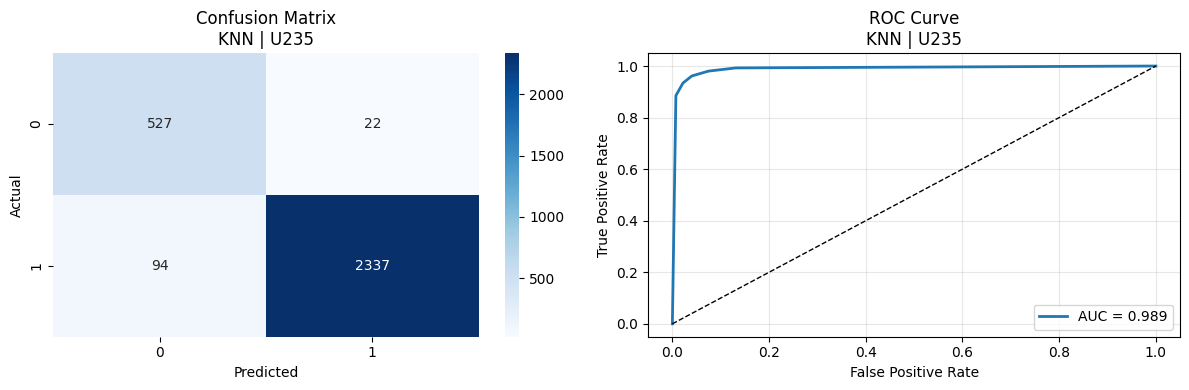


--- LGBM | U235 ---
Accuracy:  0.9728
Precision: 0.9751
Recall:    0.9728
F1:        0.9734
AUC-ROC:   0.9972
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       549
           1       1.00      0.97      0.98      2431

    accuracy                           0.97      2980
   macro avg       0.94      0.98      0.96      2980
weighted avg       0.98      0.97      0.97      2980



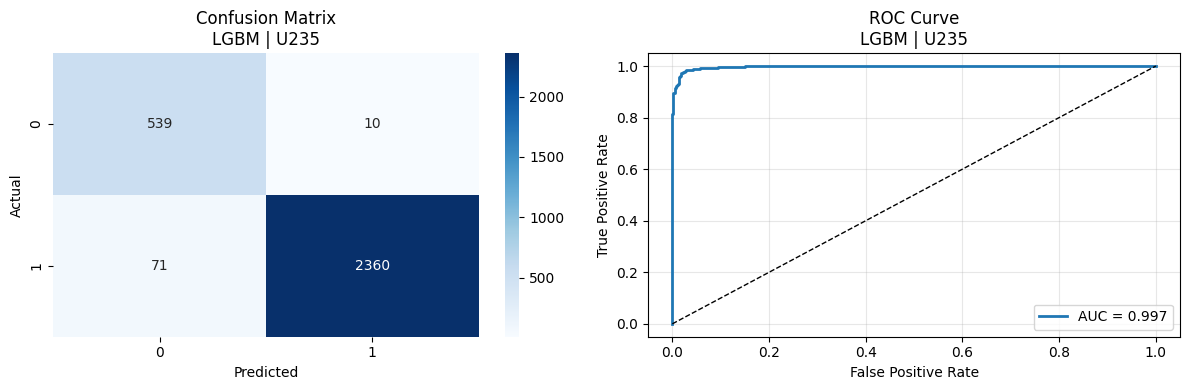

In [16]:
isotope_label = 'U235'
df_clf = clf_datasets[isotope_label]
X, y = prepare_clf_data(df_clf)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=42, stratify=y
)
print(f'{isotope_label} — Train: {X_train.shape}, Test: {X_test.shape}')

clf_results_u235 = []
for model_name, model in classifiers.items():
    result = evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name, isotope_label)
    clf_results_u235.append(result)

In [17]:
print(f'=== 5-Fold Cross-Validation — {isotope_label} ===')
for model_name, model in classifiers.items():
    m = copy.deepcopy(model)
    cv_df = cross_val_classification(m, X_scaled, y)
    print(f'\n{model_name}:')
    print(cv_df.to_string(index=False))
    print(f'  Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')

=== 5-Fold Cross-Validation — U235 ===

Extra Trees:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.987248   0.987284 0.987248 0.987118 0.996420
    2  0.990604   0.990577 0.990604 0.990564 0.997471
    3  0.987584   0.987615 0.987584 0.987462 0.998892
    4  0.991608   0.991647 0.991608 0.991544 0.999084
    5  0.987244   0.987280 0.987244 0.987114 0.997170
  Mean Accuracy: 0.9889 ± 0.0021

Random Forest:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.987584   0.987594 0.987584 0.987471 0.994985
    2  0.990268   0.990271 0.990268 0.990202 0.997012
    3  0.986242   0.986293 0.986242 0.986085 0.998630
    4  0.986573   0.986573 0.986573 0.986445 0.997982
    5  0.985230   0.985246 0.985230 0.985068 0.994759
  Mean Accuracy: 0.9872 ± 0.0019

KNN:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.953691   0.958012 0.953691 0.954876 0.986548
    2  0.959732   0.963771 0.959732 0.960762 0.990556
    3  0.957047   0.960120 0.957047 0.957943 0.98

In [18]:
print(f'\n=== Comparative Classification Results — {isotope_label} ===')
df_summary_clf_u235 = pd.DataFrame(clf_results_u235)
print(df_summary_clf_u235.to_string(index=False))


=== Comparative Classification Results — U235 ===
        model isotope  accuracy  precision   recall       f1      auc
  Extra Trees    U235  0.988255   0.988258 0.988255 0.988157 0.998225
Random Forest    U235  0.988926   0.988924 0.988926 0.988842 0.998235
          KNN    U235  0.961074   0.964506 0.961074 0.961979 0.988671
         LGBM    U235  0.972819   0.975115 0.972819 0.973361 0.997243


### 4.4 Pu239-Only Classification

Pu239 — Train: (11918, 65), Test: (2980, 65)

--- Extra Trees | Pu239 ---
Accuracy:  0.9893
Precision: 0.9892
Recall:    0.9893
F1:        0.9892
AUC-ROC:   0.9985
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       549
           1       0.99      1.00      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.98      0.98      2980
weighted avg       0.99      0.99      0.99      2980



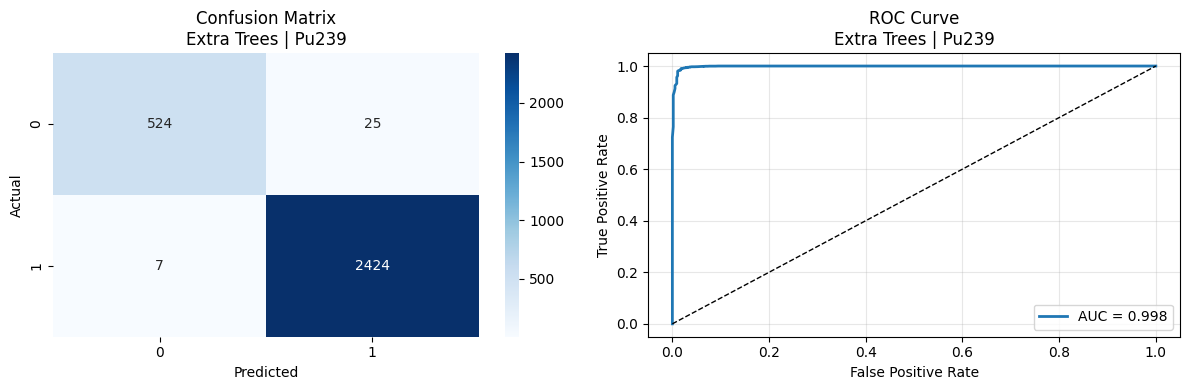


--- Random Forest | Pu239 ---
Accuracy:  0.9883
Precision: 0.9882
Recall:    0.9883
F1:        0.9882
AUC-ROC:   0.9983
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       549
           1       0.99      1.00      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.97      0.98      2980
weighted avg       0.99      0.99      0.99      2980



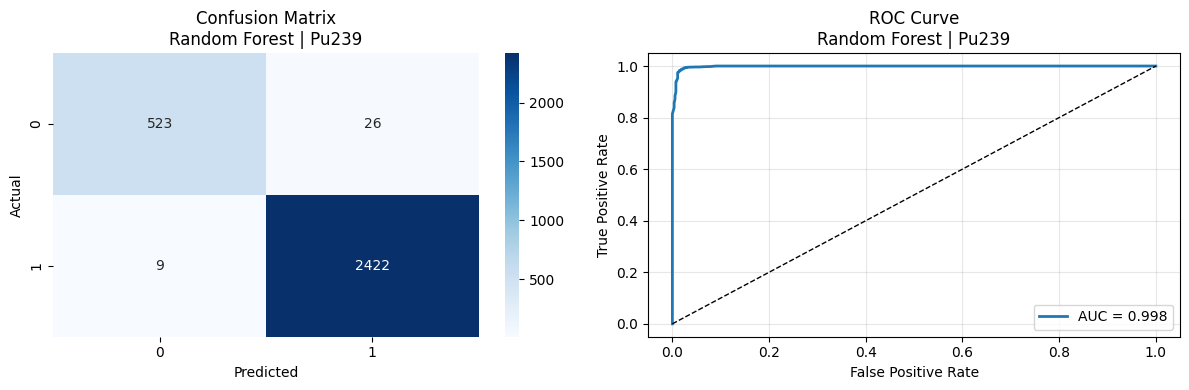


--- KNN | Pu239 ---
Accuracy:  0.9634
Precision: 0.9667
Recall:    0.9634
F1:        0.9643
AUC-ROC:   0.9913
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       549
           1       0.99      0.96      0.98      2431

    accuracy                           0.96      2980
   macro avg       0.92      0.96      0.94      2980
weighted avg       0.97      0.96      0.96      2980



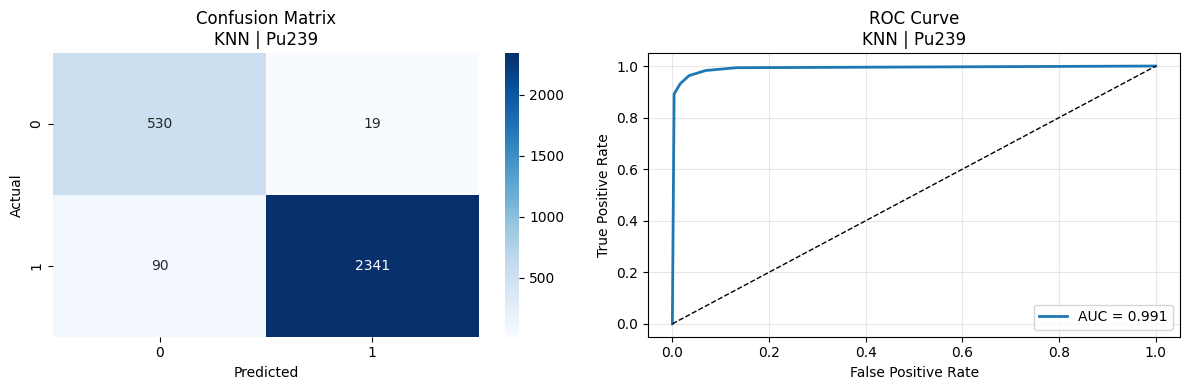


--- LGBM | Pu239 ---
Accuracy:  0.9728
Precision: 0.9745
Recall:    0.9728
F1:        0.9733
AUC-ROC:   0.9969
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       549
           1       0.99      0.97      0.98      2431

    accuracy                           0.97      2980
   macro avg       0.94      0.97      0.96      2980
weighted avg       0.97      0.97      0.97      2980



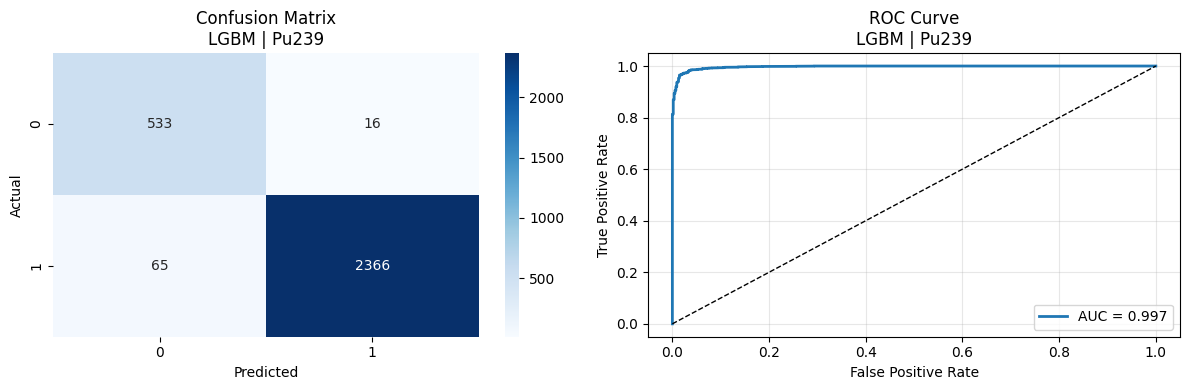

In [19]:
isotope_label = 'Pu239'
df_clf = clf_datasets[isotope_label]
X, y = prepare_clf_data(df_clf)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=42, stratify=y
)
print(f'{isotope_label} — Train: {X_train.shape}, Test: {X_test.shape}')

clf_results_pu239 = []
for model_name, model in classifiers.items():
    result = evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name, isotope_label)
    clf_results_pu239.append(result)

In [20]:
print(f'=== 5-Fold Cross-Validation — {isotope_label} ===')
for model_name, model in classifiers.items():
    m = copy.deepcopy(model)
    cv_df = cross_val_classification(m, X_scaled, y)
    print(f'\n{model_name}:')
    print(cv_df.to_string(index=False))
    print(f'  Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')

=== 5-Fold Cross-Validation — Pu239 ===

Extra Trees:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.988255   0.988300 0.988255 0.988139 0.995949
    2  0.990940   0.990918 0.990940 0.990897 0.997723
    3  0.990268   0.990306 0.990268 0.990187 0.998891
    4  0.988922   0.988957 0.988922 0.988822 0.998721
    5  0.989930   0.989935 0.989930 0.989857 0.997353
  Mean Accuracy: 0.9897 ± 0.0011

Random Forest:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.987584   0.987667 0.987584 0.987443 0.995842
    2  0.988255   0.988277 0.988255 0.988148 0.996595
    3  0.988255   0.988300 0.988255 0.988139 0.998148
    4  0.987915   0.987904 0.987915 0.987819 0.998594
    5  0.990937   0.990966 0.990937 0.990868 0.994814
  Mean Accuracy: 0.9886 ± 0.0013

KNN:
 Fold  Accuracy  Precision   Recall       F1      AUC
    1  0.956711   0.960127 0.956711 0.957680 0.988532
    2  0.955705   0.960375 0.955705 0.956915 0.990525
    3  0.954362   0.959406 0.954362 0.955661 0.9

In [21]:
print(f'\n=== Comparative Classification Results — {isotope_label} ===')
df_summary_clf_pu239 = pd.DataFrame(clf_results_pu239)
print(df_summary_clf_pu239.to_string(index=False))


=== Comparative Classification Results — Pu239 ===
        model isotope  accuracy  precision   recall       f1      auc
  Extra Trees   Pu239  0.989262   0.989244 0.989262 0.989192 0.998499
Random Forest   Pu239  0.988255   0.988219 0.988255 0.988183 0.998295
          KNN   Pu239  0.963423   0.966690 0.963423 0.964263 0.991344
         LGBM   Pu239  0.972819   0.974496 0.972819 0.973261 0.996901


### 4.5 Final Classification Comparison Across All Scenarios

In [22]:
all_clf_results = (
    clf_results_combined + clf_results_u238 + clf_results_u235 + clf_results_pu239
)
df_all_clf = pd.DataFrame(all_clf_results)
df_all_clf['auc'] = df_all_clf['auc'].round(4)

print('=== Full Classification Summary ===')
print(df_all_clf.to_string(index=False))

# Pivot for easy reading
df_pivot_clf = df_all_clf.pivot(index='model', columns='isotope', values='accuracy').round(4)
print('\n=== Accuracy by Model and Isotope ===')
print(df_pivot_clf)

=== Full Classification Summary ===
        model  isotope  accuracy  precision   recall       f1    auc
  Extra Trees Combined  0.992617   0.992644 0.992617 0.992570 0.9991
Random Forest Combined  0.990940   0.990937 0.990940 0.990884 0.9987
          KNN Combined  0.968792   0.972476 0.968792 0.969600 0.9940
         LGBM Combined  0.988926   0.989025 0.988926 0.988961 0.9990
  Extra Trees     U238  0.997987   0.997987 0.997987 0.997984 0.9997
Random Forest     U238  0.993960   0.993960 0.993960 0.993960 0.9994
          KNN     U238  0.952685   0.961960 0.952685 0.954623 0.9909
         LGBM     U238  0.976174   0.978138 0.976174 0.976621 0.9982
  Extra Trees     U235  0.988255   0.988258 0.988255 0.988157 0.9982
Random Forest     U235  0.988926   0.988924 0.988926 0.988842 0.9982
          KNN     U235  0.961074   0.964506 0.961074 0.961979 0.9887
         LGBM     U235  0.972819   0.975115 0.972819 0.973361 0.9972
  Extra Trees    Pu239  0.989262   0.989244 0.989262 0.989192 0.998

## 5. Regression Models
**Task**: Predict number of replaced pins (0–130)  
**Models**: Extra Trees, Random Forest, KNN, LightGBM  
**Scenarios**: Combined, U238-only, U235-only, Pu239-only

In [23]:
regressors = {
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=100, max_depth=None, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=2,
        bootstrap=False, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=None, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=2,
        bootstrap=True, random_state=RANDOM_STATE
    ),
    'KNN': KNeighborsRegressor(
        n_neighbors=5, weights='uniform', metric='minkowski'
    ),
    'LGBM': lgb.LGBMRegressor(
        n_estimators=100, learning_rate=0.1, num_leaves=31,
        random_state=RANDOM_STATE, verbose=-1
    ),
}

# Regression datasets
reg_datasets = {
    'Combined': df_combined_reg,
    'U238':     df_u238_reg,
    'U235':     df_u235_reg,
    'Pu239':    df_pu239_reg,
}

print('Regressors and datasets ready.')

Regressors and datasets ready.


### 5.1 Combined Regression (U238 + U235 + Pu239)

Combined Regression — Train: (11918, 195), Test: (2980, 195)

--- Extra Trees | Combined ---
MAE:  3.5922
RMSE: 7.2929
R²:   0.9782


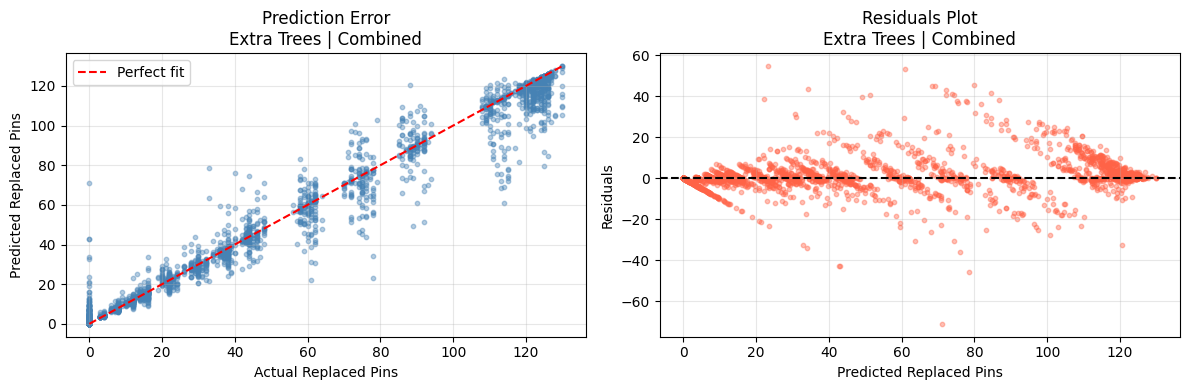


--- Random Forest | Combined ---
MAE:  4.0691
RMSE: 7.7422
R²:   0.9754


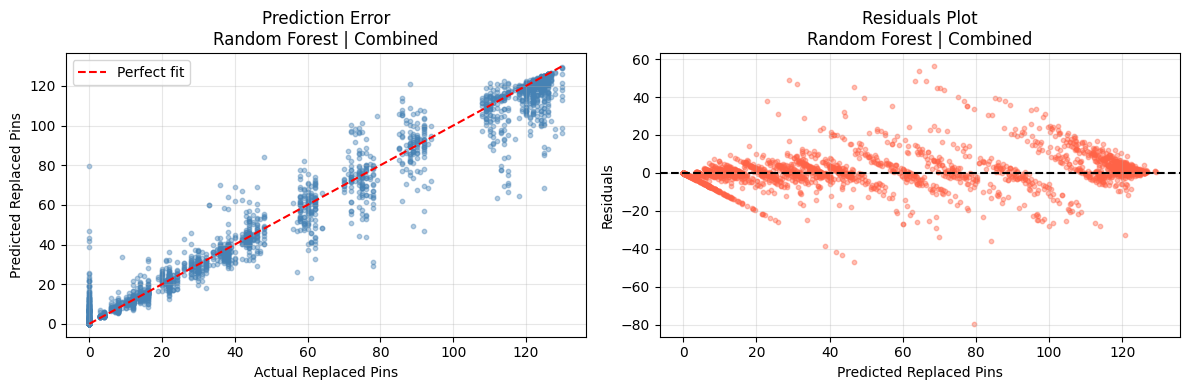


--- KNN | Combined ---
MAE:  5.2468
RMSE: 12.9385
R²:   0.9313


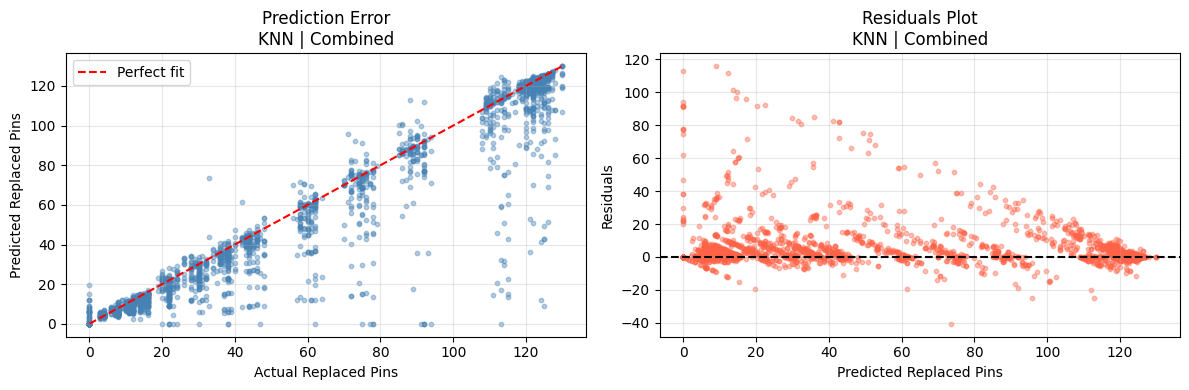


--- LGBM | Combined ---
MAE:  4.4256
RMSE: 7.2355
R²:   0.9785


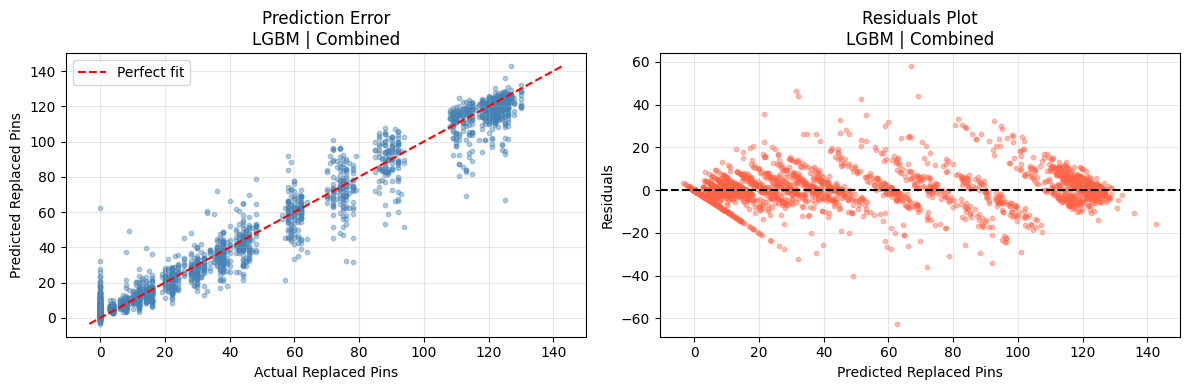

In [24]:
isotope_label = 'Combined'
df_reg = reg_datasets[isotope_label]
X, y = prepare_reg_data(df_reg)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=42
)
print(f'{isotope_label} Regression — Train: {X_train.shape}, Test: {X_test.shape}')

reg_results_combined = []
for model_name, model in regressors.items():
    result = evaluate_regressor(model, X_train, X_test, y_train, y_test, model_name, isotope_label)
    reg_results_combined.append(result)

In [25]:
print(f'=== 5-Fold Cross-Validation — {isotope_label} Regression ===')
for model_name, model in regressors.items():
    m = copy.deepcopy(model)
    cv_df = cross_val_regression(m, X_scaled, y)
    print(f'\n{model_name}:')
    print(cv_df.to_string(index=False))
    print(f'  Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
    print(f'  Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

=== 5-Fold Cross-Validation — Combined Regression ===

Extra Trees:
 Fold      MAE     RMSE       R2
    1 3.661906 7.104113 0.978769
    2 3.493174 6.711765 0.981057
    3 3.612087 7.252136 0.978445
    4 3.763652 7.090729 0.979171
    5 3.632299 6.976544 0.979195
  Mean MAE:  3.6326 ± 0.0973
  Mean R²:   0.9793 ± 0.0010

Random Forest:
 Fold      MAE     RMSE       R2
    1 4.179966 7.721953 0.974916
    2 3.907822 7.017434 0.979293
    3 4.112708 7.754290 0.975357
    4 4.270050 7.911463 0.974071
    5 4.070856 7.516917 0.975847
  Mean MAE:  4.1083 ± 0.1350
  Mean R²:   0.9759 ± 0.0020

KNN:
 Fold      MAE      RMSE       R2
    1 5.448658 13.532725 0.922961
    2 5.363356 13.256467 0.926103
    3 5.129732 12.518568 0.935773
    4 5.459752 13.294537 0.926781
    5 5.113259 12.518864 0.933008
  Mean MAE:  5.3030 ± 0.1699
  Mean R²:   0.9289 ± 0.0053

LGBM:
 Fold      MAE     RMSE       R2
    1 4.713826 7.586898 0.975786
    2 4.505029 7.631593 0.975509
    3 4.558310 7.623692 0.9761

### 5.2 U238-Only Regression

U238 Regression — Train: (11918, 65), Test: (2980, 65)

--- Extra Trees | U238 ---
MAE:  5.7459
RMSE: 9.7222
R²:   0.9612


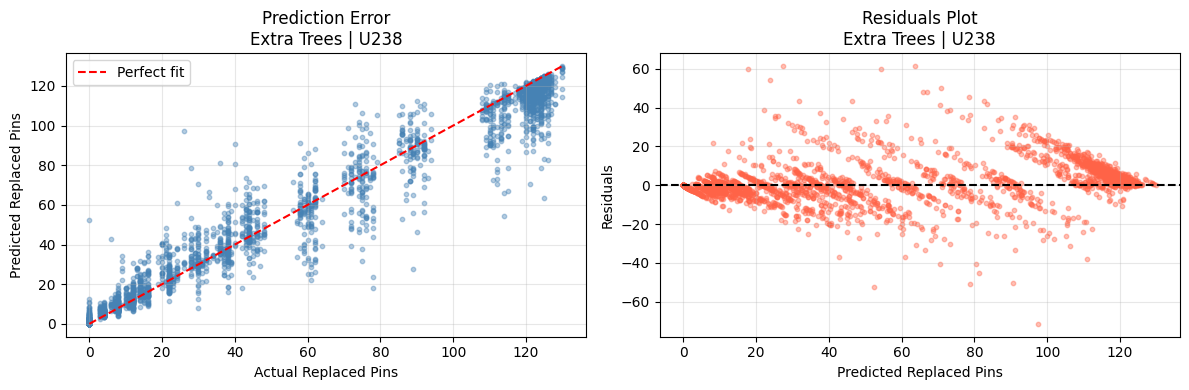


--- Random Forest | U238 ---
MAE:  6.7376
RMSE: 10.8203
R²:   0.9519


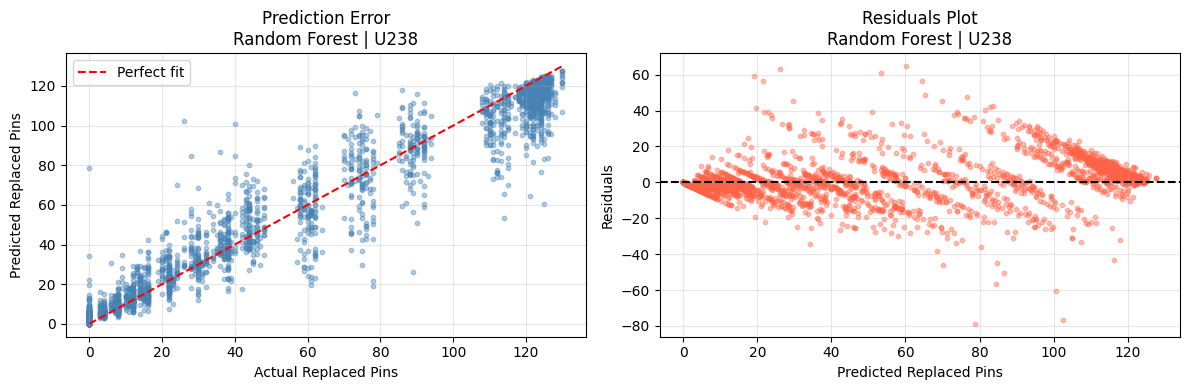


--- KNN | U238 ---
MAE:  9.0308
RMSE: 16.3808
R²:   0.8898


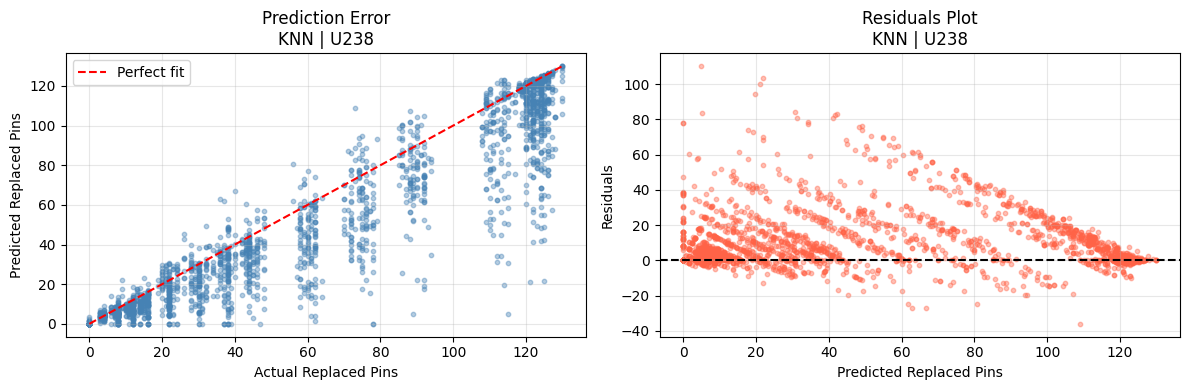


--- LGBM | U238 ---
MAE:  7.6404
RMSE: 11.7918
R²:   0.9429


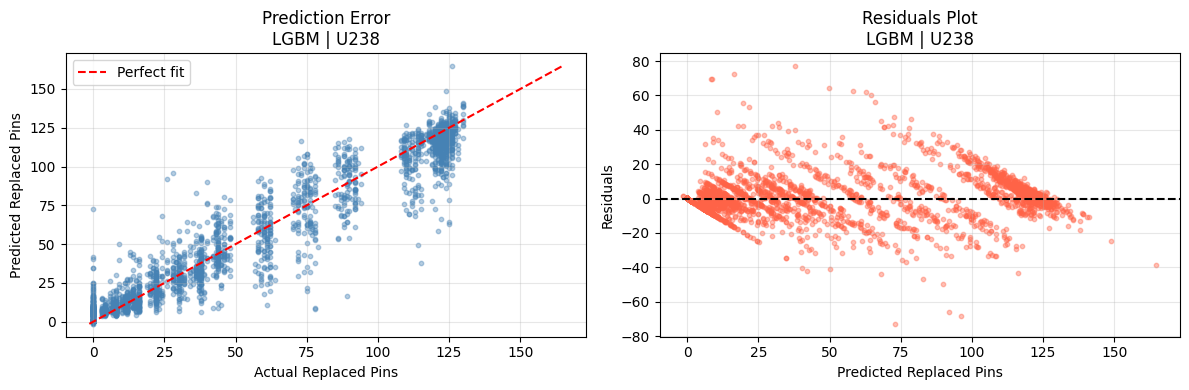

In [26]:
isotope_label = 'U238'
df_reg = reg_datasets[isotope_label]
X, y = prepare_reg_data(df_reg)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=42
)
print(f'{isotope_label} Regression — Train: {X_train.shape}, Test: {X_test.shape}')

reg_results_u238 = []
for model_name, model in regressors.items():
    result = evaluate_regressor(model, X_train, X_test, y_train, y_test, model_name, isotope_label)
    reg_results_u238.append(result)

In [27]:
print(f'=== 5-Fold Cross-Validation — {isotope_label} Regression ===')
for model_name, model in regressors.items():
    m = copy.deepcopy(model)
    cv_df = cross_val_regression(m, X_scaled, y)
    print(f'\n{model_name}:')
    print(cv_df.to_string(index=False))
    print(f'  Mean MAE: {cv_df["MAE"].mean():.4f}  Mean R²: {cv_df["R2"].mean():.4f}')

=== 5-Fold Cross-Validation — U238 Regression ===

Extra Trees:
 Fold      MAE      RMSE       R2
    1 6.094899 10.307752 0.955304
    2 5.984178 10.160096 0.956592
    3 5.937383 10.156201 0.957726
    4 6.218580 10.382402 0.955344
    5 6.239151 10.437825 0.953430
  Mean MAE: 6.0948  Mean R²: 0.9557

Random Forest:
 Fold      MAE      RMSE       R2
    1 7.133842 11.379496 0.945526
    2 6.955826 11.133041 0.947881
    3 6.962386 11.232830 0.948289
    4 7.090540 11.199409 0.948040
    5 7.210299 11.369758 0.944742
  Mean MAE: 7.0706  Mean R²: 0.9469

KNN:
 Fold      MAE      RMSE       R2
    1 9.363289 16.842990 0.880661
    2 8.909530 16.136235 0.890510
    3 9.269463 16.702827 0.885663
    4 9.839074 17.734487 0.869708
    5 9.498355 17.087229 0.875195
  Mean MAE: 9.3759  Mean R²: 0.8803

LGBM:
 Fold      MAE      RMSE       R2
    1 8.158897 12.384093 0.935483
    2 8.083064 12.592643 0.933319
    3 7.792077 12.112365 0.939873
    4 7.866307 12.019819 0.940148
    5 7.952907 12

### 5.3 U235-Only Regression

U235 Regression — Train: (11918, 65), Test: (2980, 65)

--- Extra Trees | U235 ---
MAE:  4.3750
RMSE: 9.5415
R²:   0.9626


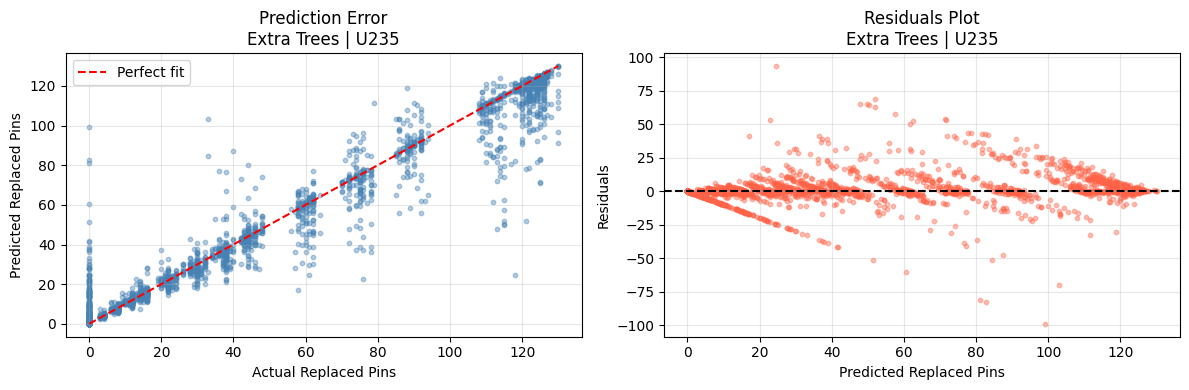


--- Random Forest | U235 ---
MAE:  5.0574
RMSE: 10.3539
R²:   0.9560


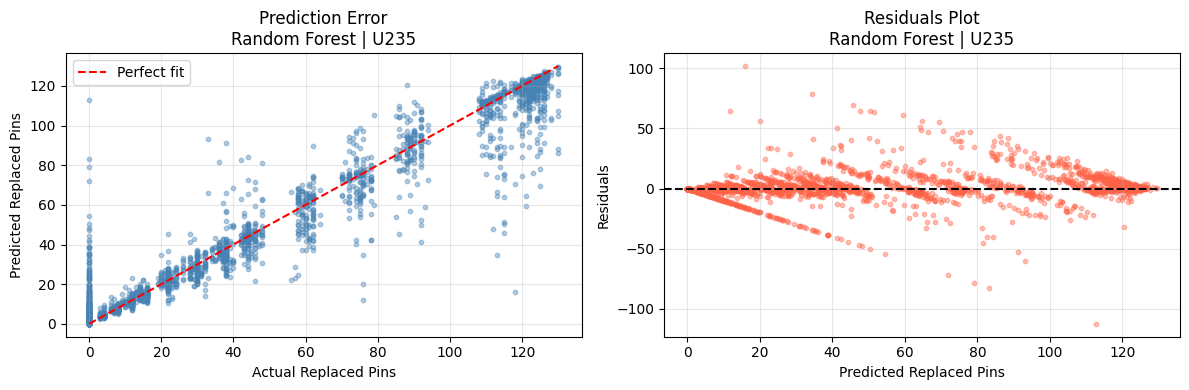


--- KNN | U235 ---
MAE:  5.5500
RMSE: 13.5276
R²:   0.9249


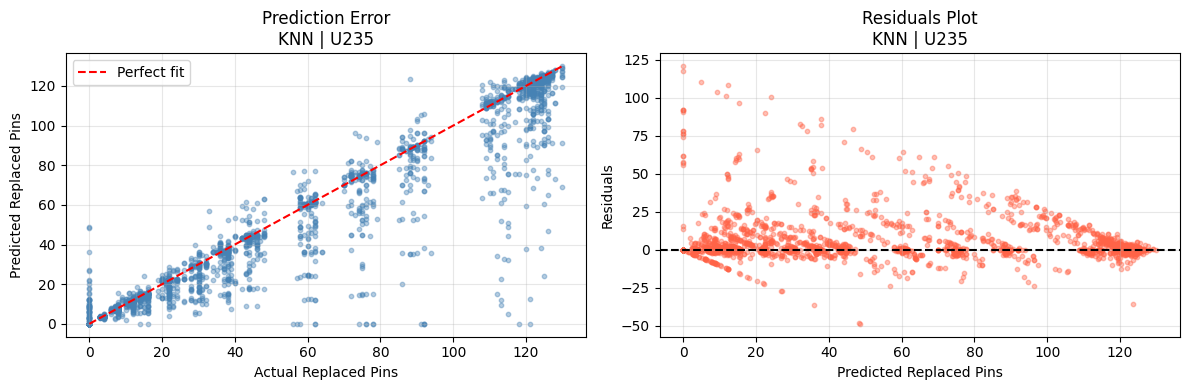


--- LGBM | U235 ---
MAE:  6.4685
RMSE: 11.0471
R²:   0.9499


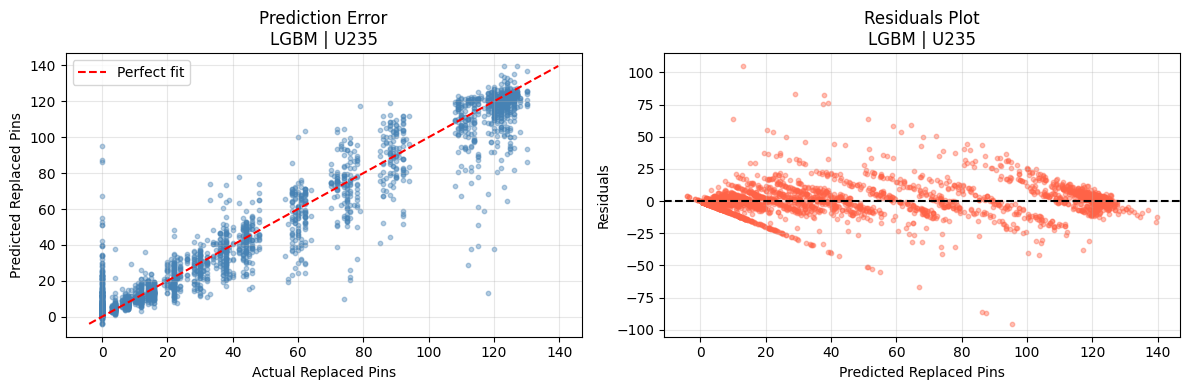

In [28]:
isotope_label = 'U235'
df_reg = reg_datasets[isotope_label]
X, y = prepare_reg_data(df_reg)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=42
)
print(f'{isotope_label} Regression — Train: {X_train.shape}, Test: {X_test.shape}')

reg_results_u235 = []
for model_name, model in regressors.items():
    result = evaluate_regressor(model, X_train, X_test, y_train, y_test, model_name, isotope_label)
    reg_results_u235.append(result)

In [29]:
print(f'=== 5-Fold Cross-Validation — {isotope_label} Regression ===')
for model_name, model in regressors.items():
    m = copy.deepcopy(model)
    cv_df = cross_val_regression(m, X_scaled, y)
    print(f'\n{model_name}:')
    print(cv_df.to_string(index=False))
    print(f'  Mean MAE: {cv_df["MAE"].mean():.4f}  Mean R²: {cv_df["R2"].mean():.4f}')

=== 5-Fold Cross-Validation — U235 Regression ===

Extra Trees:
 Fold      MAE     RMSE       R2
    1 4.331732 8.667249 0.968399
    2 4.138178 8.423559 0.970163
    3 4.333503 9.019552 0.966659
    4 4.652115 9.364405 0.963672
    5 4.191608 8.547147 0.968773
  Mean MAE: 4.3294  Mean R²: 0.9675

Random Forest:
 Fold      MAE      RMSE       R2
    1 5.050359  9.648998 0.960834
    2 4.842218  9.341482 0.963305
    3 5.152644 10.261097 0.956849
    4 5.235569  9.972288 0.958803
    5 4.894538  9.505387 0.961378
  Mean MAE: 5.0351  Mean R²: 0.9602

KNN:
 Fold      MAE      RMSE       R2
    1 5.444966 13.147797 0.927281
    2 5.612282 14.294083 0.914082
    3 5.613960 13.890708 0.920922
    4 6.051829 15.323569 0.902725
    5 5.427929 13.161776 0.925951
  Mean MAE: 5.6302  Mean R²: 0.9182

LGBM:
 Fold      MAE      RMSE       R2
    1 6.547630 10.691838 0.951911
    2 6.322208 10.591806 0.952825
    3 6.586197 10.784277 0.952336
    4 6.647039 10.757419 0.952060
    5 6.482397 10.56074

### 5.4 Pu239-Only Regression

Pu239 Regression — Train: (11918, 65), Test: (2980, 65)

--- Extra Trees | Pu239 ---
MAE:  4.2730
RMSE: 8.9248
R²:   0.9673


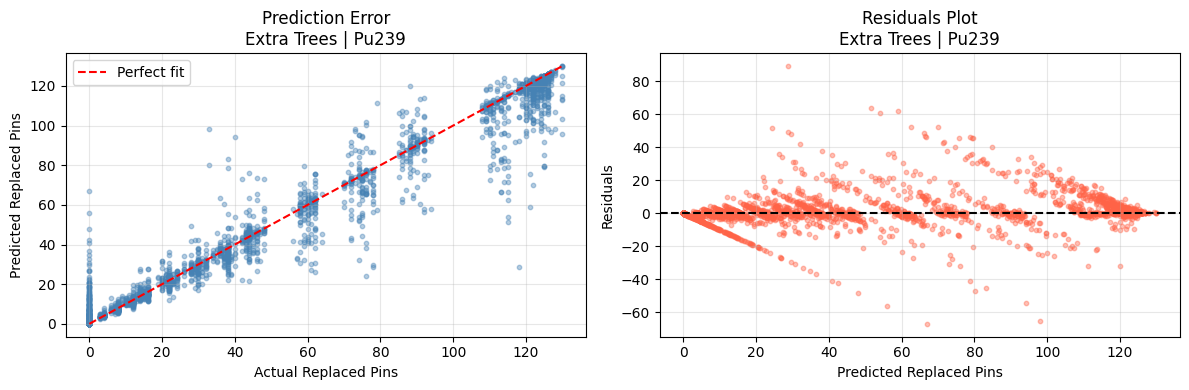


--- Random Forest | Pu239 ---
MAE:  4.9597
RMSE: 9.6461
R²:   0.9618


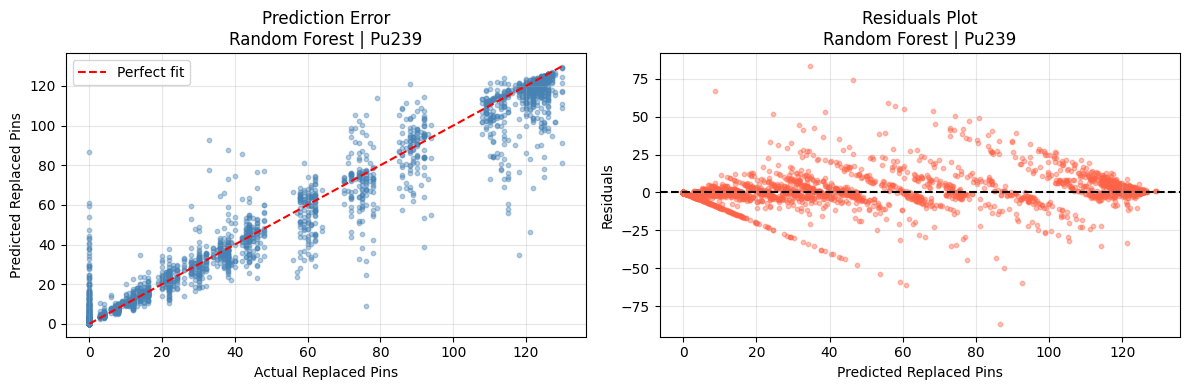


--- KNN | Pu239 ---
MAE:  5.8873
RMSE: 13.4984
R²:   0.9252


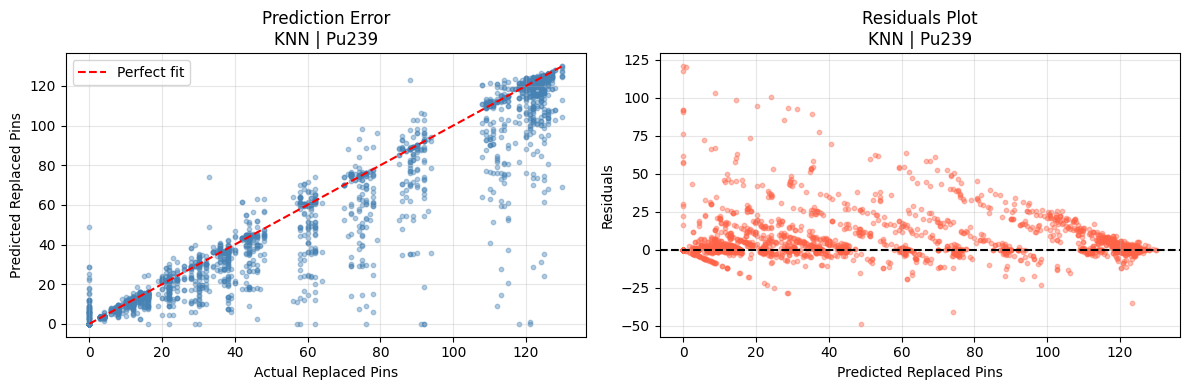


--- LGBM | Pu239 ---
MAE:  6.4784
RMSE: 10.6111
R²:   0.9538


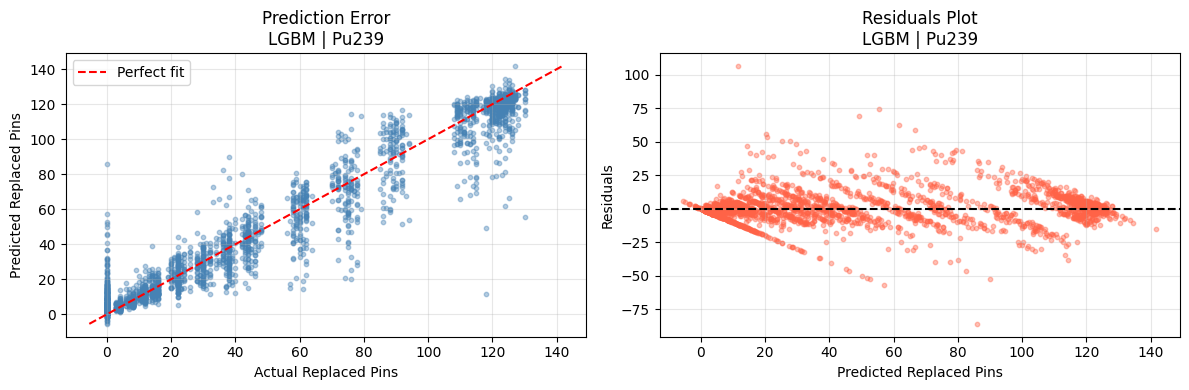

In [30]:
isotope_label = 'Pu239'
df_reg = reg_datasets[isotope_label]
X, y = prepare_reg_data(df_reg)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=42
)
print(f'{isotope_label} Regression — Train: {X_train.shape}, Test: {X_test.shape}')

reg_results_pu239 = []
for model_name, model in regressors.items():
    result = evaluate_regressor(model, X_train, X_test, y_train, y_test, model_name, isotope_label)
    reg_results_pu239.append(result)

In [31]:
print(f'=== 5-Fold Cross-Validation — {isotope_label} Regression ===')
for model_name, model in regressors.items():
    m = copy.deepcopy(model)
    cv_df = cross_val_regression(m, X_scaled, y)
    print(f'\n{model_name}:')
    print(cv_df.to_string(index=False))
    print(f'  Mean MAE: {cv_df["MAE"].mean():.4f}  Mean R²: {cv_df["R2"].mean():.4f}')

=== 5-Fold Cross-Validation — Pu239 Regression ===

Extra Trees:
 Fold      MAE     RMSE       R2
    1 4.381792 8.759803 0.967720
    2 4.205846 8.492653 0.969671
    3 4.321446 8.974293 0.966993
    4 4.629510 9.432250 0.963144
    5 4.260507 8.451308 0.969469
  Mean MAE: 4.3598  Mean R²: 0.9674

Random Forest:
 Fold      MAE      RMSE       R2
    1 5.143869  9.635788 0.960941
    2 4.894289  9.259046 0.963950
    3 5.026839  9.645662 0.961870
    4 5.325321 10.164444 0.957200
    5 4.936777  9.219616 0.963666
  Mean MAE: 5.0654  Mean R²: 0.9615

KNN:
 Fold      MAE      RMSE       R2
    1 5.858121 13.417318 0.924269
    2 6.001745 14.306688 0.913931
    3 5.724765 13.107427 0.929589
    4 6.300772 15.064731 0.905984
    5 5.533468 12.930414 0.928531
  Mean MAE: 5.8838  Mean R²: 0.9205

LGBM:
 Fold      MAE      RMSE       R2
    1 6.851869 11.110168 0.948074
    2 6.460767 10.612993 0.952636
    3 6.703117 10.893302 0.951367
    4 6.993169 11.305034 0.947055
    5 6.518438 10.4042

### 5.5 Final Regression Comparison Across All Scenarios

In [32]:
all_reg_results = (
    reg_results_combined + reg_results_u238 + reg_results_u235 + reg_results_pu239
)
df_all_reg = pd.DataFrame(all_reg_results).round(4)

print('=== Full Regression Summary ===')
print(df_all_reg.to_string(index=False))

df_pivot_reg = df_all_reg.pivot(index='model', columns='isotope', values='R2').round(4)
print('\n=== R² by Model and Isotope ===')
print(df_pivot_reg)

=== Full Regression Summary ===
        model  isotope    MAE    RMSE     R2
  Extra Trees Combined 3.5922  7.2929 0.9782
Random Forest Combined 4.0691  7.7422 0.9754
          KNN Combined 5.2468 12.9385 0.9313
         LGBM Combined 4.4256  7.2355 0.9785
  Extra Trees     U238 5.7459  9.7222 0.9612
Random Forest     U238 6.7376 10.8203 0.9519
          KNN     U238 9.0308 16.3808 0.8898
         LGBM     U238 7.6404 11.7918 0.9429
  Extra Trees     U235 4.3750  9.5415 0.9626
Random Forest     U235 5.0574 10.3539 0.9560
          KNN     U235 5.5500 13.5276 0.9249
         LGBM     U235 6.4685 11.0471 0.9499
  Extra Trees    Pu239 4.2730  8.9248 0.9673
Random Forest    Pu239 4.9597  9.6461 0.9618
          KNN    Pu239 5.8873 13.4984 0.9252
         LGBM    Pu239 6.4784 10.6111 0.9538

=== R² by Model and Isotope ===
isotope        Combined   Pu239    U235    U238
model                                          
Extra Trees      0.9782  0.9673  0.9626  0.9612
KNN              0.9313  0

## 6. Summary Dashboard

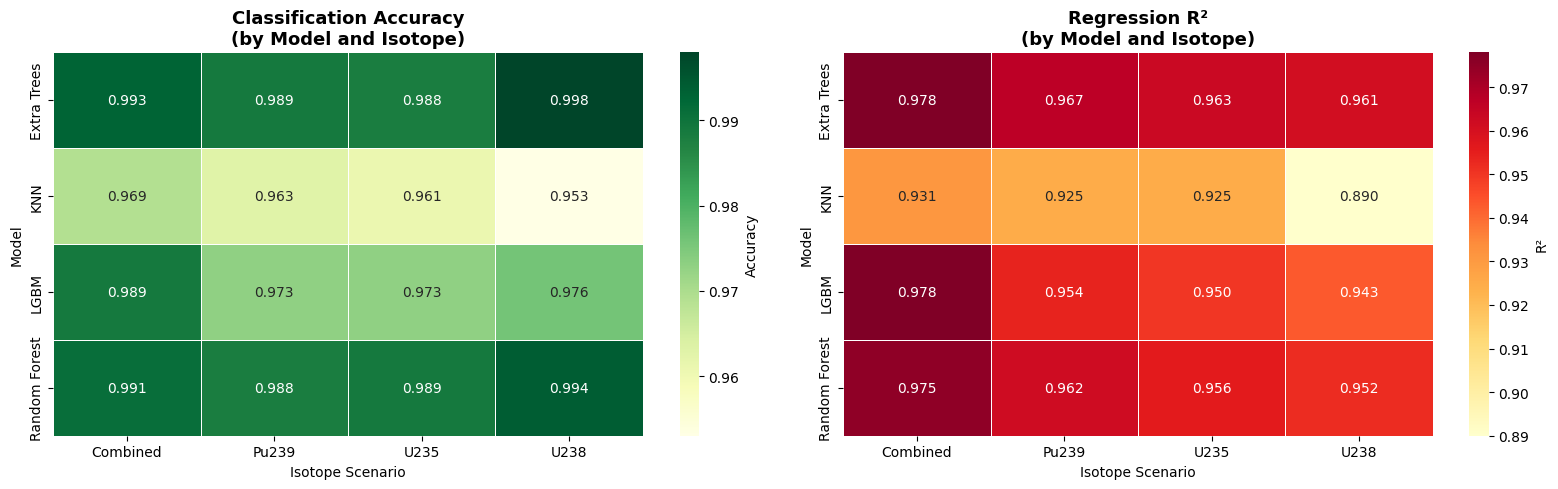

Final summary saved.


In [33]:
# Final summary plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Classification accuracy heatmap
df_acc = df_all_clf.pivot(index='model', columns='isotope', values='accuracy').round(3)
sns.heatmap(df_acc, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Accuracy'})
axes[0].set_title('Classification Accuracy\n(by Model and Isotope)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Isotope Scenario')
axes[0].set_ylabel('Model')

# Regression R² heatmap
df_r2 = df_all_reg.pivot(index='model', columns='isotope', values='R2').round(3)
sns.heatmap(df_r2, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'R²'})
axes[1].set_title('Regression R²\n(by Model and Isotope)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Isotope Scenario')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.savefig('final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final summary saved.')

In [34]:
# Export all results to Excel
with pd.ExcelWriter('thesis_results.xlsx') as writer:
    df_all_clf.to_excel(writer, sheet_name='Classification', index=False)
    df_all_reg.to_excel(writer, sheet_name='Regression', index=False)
    df_acc.to_excel(writer, sheet_name='Accuracy_Pivot')
    df_r2.to_excel(writer, sheet_name='R2_Pivot')

print('Results exported to thesis_results.xlsx')

Results exported to thesis_results.xlsx
